# 04 — Credit Risk Analysis

**Objective:** Model the P&L impact of a counterparty (customer or supplier) default on Interfood, generalising the real 2025 AS E-Piim Tootmine write-off (€14.3m) into a repeatable framework across exposure sizes and recovery rates.

**Inputs:**
- `../data/interfood.db` (net result, sales, gross income for context)

**Expected output:**
- A framework relating default exposure → loss → P&L impact, expressed as a share of annual profit and margin, with sensitivity tables and charts.

**Why this matters for Interfood specifically:**
A dairy trader extends credit to counterparties (selling on payment terms, or prepaying/committing to suppliers). On a **thin margin (~3–4%)**, a single counterparty default destroys a disproportionate amount of profit — because the loss is against the *full exposure*, while the earnings that must absorb it are only a few percent of revenue. The E-Piim write-off is the concrete proof: one supplier failure was the largest single drag on 2025 net income. This notebook quantifies that leverage.

## Step 1 — The E-Piim anchor: why a default hurts a thin-margin trader

The core insight, in numbers. If Interfood earns a net margin of ~1–2%, then to *generate* €X of profit it must transact a large multiple of €X in revenue. A default wipes out profit at the **full loss amount** — so a loss of €L erases the profit earned on many multiples of €L in sales. We make this explicit first.

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

data_dir = Path("../data")
charts_dir = Path("../outputs/charts")
charts_dir.mkdir(parents=True, exist_ok=True)

conn = sqlite3.connect(data_dir / "interfood.db")
wide = (pd.read_sql_query("SELECT * FROM summary_series", conn)
        .pivot(index="year", columns="metric", values="value").sort_index())
conn.close()

# 2025 context (values in EUR '000)
YEAR = 2025
sales_25   = wide.loc[YEAR, "sales"]
net_25     = wide.loc[YEAR, "net_result"]
gross_25   = wide.loc[YEAR, "gross_operating_income"]
net_margin = net_25 / sales_25

# The actual E-Piim write-off (from 2025 report narrative), in EUR '000
EPIIM_WRITEOFF = 14300

print(f"2025 sales:        €{sales_25/1000:,.0f}m")
print(f"2025 net result:   €{net_25/1000:,.1f}m")
print(f"2025 net margin:   {net_margin:.2%}")
print(f"E-Piim write-off:  €{EPIIM_WRITEOFF/1000:,.1f}m")
print(f"\nWrite-off as % of net result: {EPIIM_WRITEOFF/net_25:.0%}")
print(f"Sales-equivalent wiped out:   €{EPIIM_WRITEOFF/net_margin/1000:,.0f}m of revenue-worth of profit")

2025 sales:        €3,480m
2025 net result:   €20.8m
2025 net margin:   0.60%
E-Piim write-off:  €14.3m

Write-off as % of net result: 69%
Sales-equivalent wiped out:   €2,392m of revenue-worth of profit


### Result

This is the headline insight for the whole module: the €14.3m E-Piim write-off equalled roughly **69% of Interfood's entire 2025 net result** — a single counterparty consumed more than two-thirds of the year's profit. Put differently, at a ~0.6% net margin, that loss erased the profit earned on **billions of euros** of trading. This is the leverage of credit risk in a thin-margin business, and it's exactly why the Business Control role includes customer *and* supplier credit assessment as a core, daily task rather than a formality.

## Step 2 — Generalise: default loss across exposure and recovery

A default doesn't always mean total loss. The realised loss depends on:
- **Exposure at default (EAD)** — how much Interfood is owed / has committed.
- **Recovery rate (R)** — the fraction recovered (via insurance, security, collateral, or bankruptcy proceeds).

**Loss = EAD × (1 − R).**

Interfood mitigates with accounts-receivable **credit insurance**, letters of credit, and prepayment controls — so recovery is rarely zero. We model loss across a grid of exposures and recovery rates, then express each loss as a share of 2025 net result.

In [2]:
# Grid: exposure at default (EUR '000) x recovery rate
exposures = np.array([5_000, 10_000, 14_300, 20_000, 30_000, 50_000])  # €5m ... €50m
recoveries = np.array([0.0, 0.25, 0.50, 0.75])

def loss(ead, r):
    return ead * (1 - r)

# Loss table (EUR m)
loss_tbl = pd.DataFrame(
    {f"R={int(r*100)}%": [loss(e, r)/1000 for e in exposures] for r in recoveries},
    index=[f"€{e/1000:,.1f}m" for e in exposures]
)
loss_tbl.index.name = "Exposure at default"
print("Loss given default (€m):")
loss_tbl.round(1)

Loss given default (€m):


,R=0%,R=25%,R=50%,R=75%
Exposure at default,,,,
€5.0m,5.0,3.8,2.5,1.2
€10.0m,10.0,7.5,5.0,2.5
€14.3m,14.3,10.7,7.2,3.6
€20.0m,20.0,15.0,10.0,5.0
€30.0m,30.0,22.5,15.0,7.5
€50.0m,50.0,37.5,25.0,12.5


In [3]:
# Same grid, but expressed as % of 2025 net result — the "how much profit does this erase" view
impact_tbl = pd.DataFrame(
    {f"R={int(r*100)}%": [100*loss(e, r)/net_25 for e in exposures] for r in recoveries},
    index=[f"€{e/1000:,.1f}m" for e in exposures]
)
impact_tbl.index.name = "Exposure at default"
print("Loss as % of 2025 net result (€20.8m):")
impact_tbl.round(0)

Loss as % of 2025 net result (€20.8m):


,R=0%,R=25%,R=50%,R=75%
Exposure at default,,,,
€5.0m,24.0,18.0,12.0,6.0
€10.0m,48.0,36.0,24.0,12.0
€14.3m,69.0,52.0,34.0,17.0
€20.0m,96.0,72.0,48.0,24.0
€30.0m,144.0,108.0,72.0,36.0
€50.0m,240.0,180.0,120.0,60.0


### Result

The percentage table is the striking one. Even a **€10m exposure with 50% recovery** (a €5m loss) erases ~24% of a year like 2025's profit. With no recovery, a €30–50m exposure would wipe out the entire year's earnings. This is why credit *limits* per counterparty exist, and why recovery mechanisms (insurance, LCs, collateral) are not optional extras — they're the difference between a manageable loss and a year-destroying one. The recovery rate is the single biggest lever a controller has after the exposure limit itself.

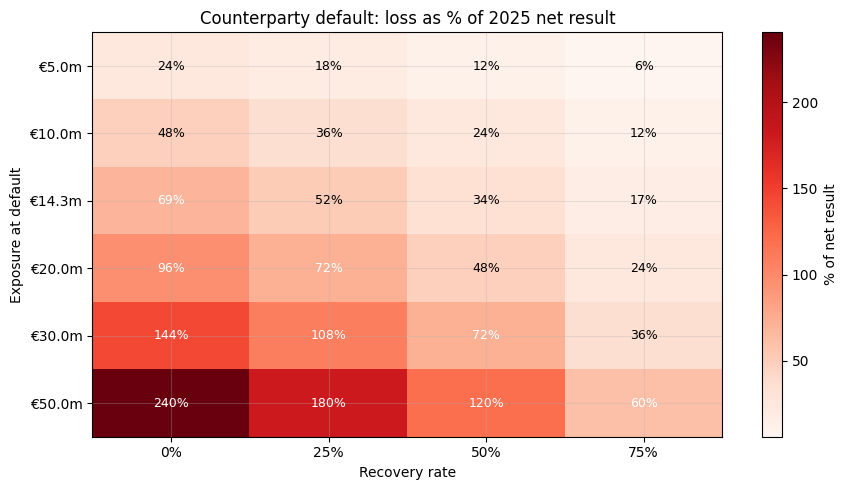

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
data = impact_tbl.values
im = ax.imshow(data, cmap="Reds", aspect="auto")

ax.set_xticks(range(len(recoveries)))
ax.set_xticklabels([f"{int(r*100)}%" for r in recoveries])
ax.set_yticks(range(len(exposures)))
ax.set_yticklabels([f"€{e/1000:,.1f}m" for e in exposures])
ax.set_xlabel("Recovery rate"); ax.set_ylabel("Exposure at default")
ax.set_title("Counterparty default: loss as % of 2025 net result")

# annotate cells
for i in range(len(exposures)):
    for j in range(len(recoveries)):
        val = data[i, j]
        ax.text(j, i, f"{val:.0f}%", ha="center", va="center",
                color="white" if val > 60 else "black", fontsize=9)

plt.colorbar(im, ax=ax, label="% of net result")
fig.tight_layout()
plt.savefig(charts_dir / "06_credit_risk_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

## Step 3 — Portfolio view: expected loss and concentration

Individual defaults are one lens; the portfolio is another. **Expected loss** across a book of counterparties is:

**EL = Σ (PD_i × EAD_i × (1 − R_i))**

where PD = probability of default. We can't see Interfood's actual book, so this is an **illustrative** portfolio to show the mechanics and — importantly — the effect of **concentration** (one large counterparty vs many small ones for the same total exposure).

In [5]:
rng = np.random.default_rng(42)

def expected_loss(exposures_km, pd_rate, recovery):
    """exposures in €'000; returns total EL in €'000."""
    return np.sum(np.array(exposures_km) * pd_rate * (1 - recovery))

TOTAL_BOOK = 300_000     # €300m illustrative receivables book (€'000)
PD = 0.02                # 2% annual default probability (illustrative)
REC = 0.50               # 50% recovery (insurance/LC assumed)

# Scenario A: diversified — 60 counterparties of €5m each
book_diversified = [TOTAL_BOOK/60] * 60

# Scenario B: concentrated — 1 large €100m counterparty + 40 small €5m
book_concentrated = [100_000] + [ (TOTAL_BOOK-100_000)/40 ]*40

el_div = expected_loss(book_diversified, PD, REC)
el_con = expected_loss(book_concentrated, PD, REC)

# Concentration risk: worst-case single-name loss (largest exposure defaults, this recovery)
worst_div = max(book_diversified) * (1 - REC)
worst_con = max(book_concentrated) * (1 - REC)

print(f"Illustrative book: €{TOTAL_BOOK/1000:,.0f}m | PD={PD:.0%} | recovery={REC:.0%}\n")
print(f"Expected loss (diversified, 60x €5m):     €{el_div/1000:,.2f}m")
print(f"Expected loss (concentrated, 1x€100m+..): €{el_con/1000:,.2f}m")
print(f"  -> Expected loss is identical for the same total book & PD: {np.isclose(el_div, el_con)}")
print(f"\nBut worst-case SINGLE default differs enormously:")
print(f"  Diversified  worst single loss: €{worst_div/1000:,.1f}m")
print(f"  Concentrated worst single loss: €{worst_con/1000:,.1f}m  ({worst_con/net_25:.0%} of 2025 net result)")

Illustrative book: €300m | PD=2% | recovery=50%

Expected loss (diversified, 60x €5m):     €3.00m
Expected loss (concentrated, 1x€100m+..): €3.00m
  -> Expected loss is identical for the same total book & PD: True

But worst-case SINGLE default differs enormously:
  Diversified  worst single loss: €2.5m
  Concentrated worst single loss: €50.0m  (240% of 2025 net result)


### Result

The key lesson: **expected loss is the same for both books** (same total exposure, same PD), but the **concentration risk is completely different**. The diversified book's worst single default is a manageable €2.5m; the concentrated book's is €50m — enough to erase two-plus years of profit. This is exactly why the JD lists "monitor credit limits" alongside "credit risk analysis": expected loss tells you the *average* cost of doing business, but concentration limits protect you from the *catastrophic* single event. E-Piim was precisely that — a concentrated single-name failure, not an average outcome.

## Step 4 — What a credit assessment actually looks at

Translating the model into the practical task the role describes. When assessing a customer or supplier before extending credit or committing, a controller weighs:

In [6]:
assessment_framework = pd.DataFrame([
    ("Financial strength", "Counterparty's own financials — liquidity, leverage, profitability, trend", "Sets base probability of default"),
    ("Payment history",    "Track record with Interfood and trade references",                          "Behavioural signal of reliability"),
    ("Country / political risk", "Sovereign, currency, sanctions, convertibility risk of their location", "E.g. the report's KYC on Russia/Belarus counterparties"),
    ("Exposure size vs limit", "Requested exposure against an approved per-counterparty limit",          "Caps concentration / single-name risk"),
    ("Security & recovery", "Credit insurance, letters of credit, prepayment, collateral",               "Raises recovery rate; lowers loss given default"),
    ("Tenor", "How long the credit is outstanding (payment terms, delivery lag)",                        "Longer tenor = more exposure window"),
], columns=["Factor", "What you look at", "Why it matters"])

pd.set_option("display.max_colwidth", None)
assessment_framework

,Factor,What you look at,Why it matters
0,Financial strength,"Counterparty's own financials — liquidity, leverage, profitability, trend",Sets base probability of default
1,Payment history,Track record with Interfood and trade references,Behavioural signal of reliability
2,Country / political risk,"Sovereign, currency, sanctions, convertibility risk of their location",E.g. the report's KYC on Russia/Belarus counterparties
3,Exposure size vs limit,Requested exposure against an approved per-counterparty limit,Caps concentration / single-name risk
4,Security & recovery,"Credit insurance, letters of credit, prepayment, collateral",Raises recovery rate; lowers loss given default
5,Tenor,"How long the credit is outstanding (payment terms, delivery lag)",Longer tenor = more exposure window


### Result — the assessment logic (interview-ready)

These six factors map directly onto the model: **financial strength + payment history + country risk** drive the *probability of default*; **exposure vs limit** controls *concentration*; **security + tenor** set the *loss given default* (via recovery and exposure window). So a credit decision is really: *estimate PD, cap the EAD against a limit, and lift recovery through security — so that even if this name defaults, the loss is survivable against a thin margin.* That single sentence is the reasoning a Business Controller applies, and it's the honest, structured answer to "how would you assess a counterparty's credit?" — foundation shown, without overclaiming hands-on experience.

## Conclusion

**What we achieved:**
- Anchored counterparty risk on the real E-Piim write-off: €14.3m ≈ 69% of 2025 net result — one default, two-thirds of a year's profit.
- Generalised it with a **Loss = EAD × (1 − recovery)** framework across exposure/recovery grids, expressed as % of profit.
- Showed the **concentration lesson**: same expected loss, wildly different worst-case single-name risk — the reason credit *limits* exist alongside credit *analysis*.
- Laid out the practical six-factor assessment framework, mapped to PD / EAD / recovery.

**What's next:**
- **`05_three_statement_projection.ipynb`** — the driver-based three-year forecast.

**The one line to carry into an interview:** *On a ~1–3% net margin, a single counterparty default can erase most of a year's profit — E-Piim proved it in 2025 — so credit assessment isn't a formality here, it's protecting the bottom line, and the levers are the exposure limit and the recovery rate.*